# 9.3 Local and Emerging Hot Spots

**Part:** 9 — Spatio-Temporal Analysis (Chapter 9.3 of 7)

**Dataset:** `data_1998_2010_long_lbc.csv` (3,107 counties x 15 years)

**Focus:** per-year Gi* (library-supported); Mann-Kendall trend and an emerging-hot-spot categorization (hand-assembled)

**Library:** `spatialstats.cluster.getis_ord_gi` for Section 3; `pymannkendall` plus hand-built classification rules for Sections 4-5

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Per-Year Gi*](#3.-Per-Year-Gi*)
4.. [Mann-Kendall Trend of Each County's z-Score Series](#4.-Mann-Kendall-Trend-of-Each-County's-z-Score-Series)
5.. [Assembling Emerging Hot-Spot Categories by Hand](#5.-Assembling-Emerging-Hot-Spot-Categories-by-Hand)
6.. [Multiple Testing Over Space x Time](#6.-Multiple-Testing-Over-Space-x-Time)
7.. [Summary and Conclusions](#7.-Summary-and-Conclusions)
8.. [Resources](#8.-Resources)

***
## 1. Overview

Chapter 9.2's Section 3 already hinted that `RATE`'s spatial clustering shifts gradually over the 15-year panel.
This chapter goes further: rather than tracking one *global* number per year, it tracks a **local** Gi*
z-score for every county in every year, then classifies each county's own 15-year trajectory — is it a
newly-emerged hot spot, a stable one, one that is fading, or one with no consistent pattern at all?

| Step | What we do | Library status |
|------|------------|-----------------|
| Per-year Gi* | 15 independent `cluster.getis_ord_gi` calls, one fixed weights matrix | ✅ Library-supported |
| Mann-Kendall trend | Is each county's own 15-value z-score series trending up, down, or flat? | 🔨 `pymannkendall`, not `spatialstats` |
| Category assembly | New / persistent / intensifying / diminishing / sporadic / oscillating | 🔨 Hand-built classification rules |
| Multiple testing | 3,107 counties x 15 years of simultaneous tests — what actually controls the false-discovery rate here | Discussed directly |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymannkendall as mk

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.cluster import getis_ord_gi
from spatialstats.weights import KNN

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}
print(f"spatialstats : version {spatialstats.__version__}")
print(f"pymannkendall available, used for Section 4 (not a spatialstats function)")

spatialstats : version 0.2.0
pymannkendall available, used for Section 4 (not a spatialstats function)


***
## 3. Per-Year Gi*

The same fixed-weights-matrix trick from Chapter 9.2 applies here — one `KNN(k=6)` matrix, reused for all 15
independent `getis_ord_gi` calls, each with its own FDR correction across that year's 3,107 simultaneous county
tests (Section 6 returns to whether that is enough).

In [2]:
panel = pd.read_csv(DATA / "data_1998_2010_long_lbc.csv")
reference = panel[panel["Year"] == 1998].sort_values("FIPS").reset_index(drop=True)
coords = reference[["X", "Y"]].to_numpy()
w = KNN(coords, k=6)
years = sorted(panel["Year"].unique())
n_counties = len(reference)
fips_order = reference["FIPS"].to_numpy()

z_matrix = np.zeros((len(years), n_counties))
hot_matrix = np.zeros((len(years), n_counties), dtype=bool)
cold_matrix = np.zeros((len(years), n_counties), dtype=bool)

for i, year in enumerate(years):
    d = panel[panel["Year"] == year].sort_values("FIPS").reset_index(drop=True)
    assert (d["FIPS"].to_numpy() == fips_order).all()
    res = getis_ord_gi(d["RATE"].to_numpy(), w, star=True, inference="analytic", correction="fdr")
    z_matrix[i] = res.z
    hot_matrix[i] = res.hot
    cold_matrix[i] = res.cold

print(f"z_matrix shape: {z_matrix.shape}  (years x counties)")
print(f"mean hot spots per year:  {hot_matrix.sum(axis=1).mean():.0f} of {n_counties}")
print(f"mean cold spots per year: {cold_matrix.sum(axis=1).mean():.0f} of {n_counties}")

z_matrix shape: (15, 3107)  (years x counties)
mean hot spots per year:  555 of 3107
mean cold spots per year: 597 of 3107


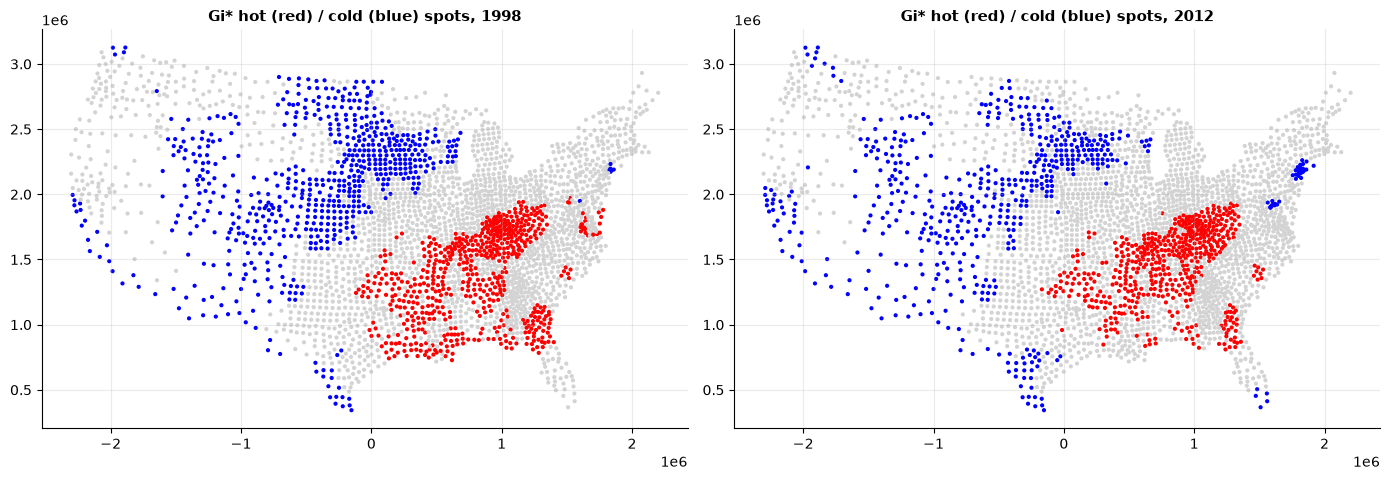

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, year_idx, title in zip(axes, [0, -1], [f"{years[0]}", f"{years[-1]}"]):
    colors = np.where(hot_matrix[year_idx], "red", np.where(cold_matrix[year_idx], "blue", "lightgrey"))
    ax.scatter(reference["X"], reference["Y"], c=colors, s=4)
    ax.set_title(f"Gi* hot (red) / cold (blue) spots, {title}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("gi_star_snapshots.png", dpi=100, bbox_inches="tight")
plt.show()

Even side by side, the two endpoint years show the hot-spot footprint is not identical — some regions present in
1998 have faded by 2012, others have newly emerged. Section 5 makes this comparison rigorous across all 15 years
at once, for every county, rather than eyeballing two snapshots.

***
## 4. Mann-Kendall Trend of Each County's z-Score Series

For every county, its own 15-value Gi* z-score series is a time series in its own right — is it trending up
(strengthening as a hot spot, or weakening as a cold spot), down, or statistically flat? The Mann-Kendall test is
a standard, non-parametric trend test — it makes no assumption about the functional form of any trend, only
about its monotonic direction, which suits a short, noisy 15-point series well.

In [4]:
mk_results = []
for j in range(n_counties):
    r = mk.original_test(z_matrix[:, j])
    mk_results.append({"trend": r.trend, "significant": bool(r.h), "p": r.p, "z_mk": r.z, "slope": r.slope})
mk_df = pd.DataFrame(mk_results)
print(mk_df["trend"].value_counts())
print(f"\nsignificant trend (any direction): {mk_df['significant'].sum()} of {n_counties} counties "
     f"({100*mk_df['significant'].mean():.1f}%)")

trend
increasing    1494
decreasing    1373
no trend       240
Name: count, dtype: int64

significant trend (any direction): 2867 of 3107 counties (92.3%)


***
## 5. Assembling Emerging Hot-Spot Categories by Hand

**No `spatialstats` function does this.** The categories below are a hand-built, transparent set of rules over
each county's 15-year `hot_matrix`/`cold_matrix`/Mann-Kendall results — not a reproduction of any particular
commercial GIS tool's proprietary algorithm, but built in the same spirit the outline describes:

In [5]:
T = len(years)


def categorize(j):
    n_hot, n_cold = hot_matrix[:, j].sum(), cold_matrix[:, j].sum()
    if n_hot > 0 and n_cold > 0:
        return "oscillating"
    if n_hot == 0 and n_cold == 0:
        return "no pattern"
    is_hot = n_hot > 0
    n_x = n_hot if is_hot else n_cold
    mat = hot_matrix if is_hot else cold_matrix
    last3, first3 = mat[-3:, j].sum(), mat[:3, j].sum()
    trend_sig, increasing = mk_df.loc[j, "significant"], mk_df.loc[j, "trend"] == "increasing"
    strengthening = increasing if is_hot else not increasing

    if n_x == 1 and last3 >= 1 and first3 == 0:
        label = "new"
    elif n_x >= 0.9 * T:
        label = "persistent"
    elif trend_sig and strengthening and last3 >= 2:
        label = "intensifying"
    elif trend_sig and (not strengthening) and first3 >= 1 and last3 == 0:
        label = "diminishing"
    else:
        label = "sporadic"
    return f"{label} {'hot' if is_hot else 'cold'} spot"


categories = pd.Series([categorize(j) for j in range(n_counties)], index=fips_order, name="category")
categories.value_counts()

category
no pattern                1732
persistent cold spot       495
persistent hot spot        469
diminishing hot spot       138
diminishing cold spot      132
intensifying cold spot      65
intensifying hot spot       45
sporadic cold spot          12
sporadic hot spot            9
new cold spot                5
new hot spot                 5
Name: count, dtype: int64

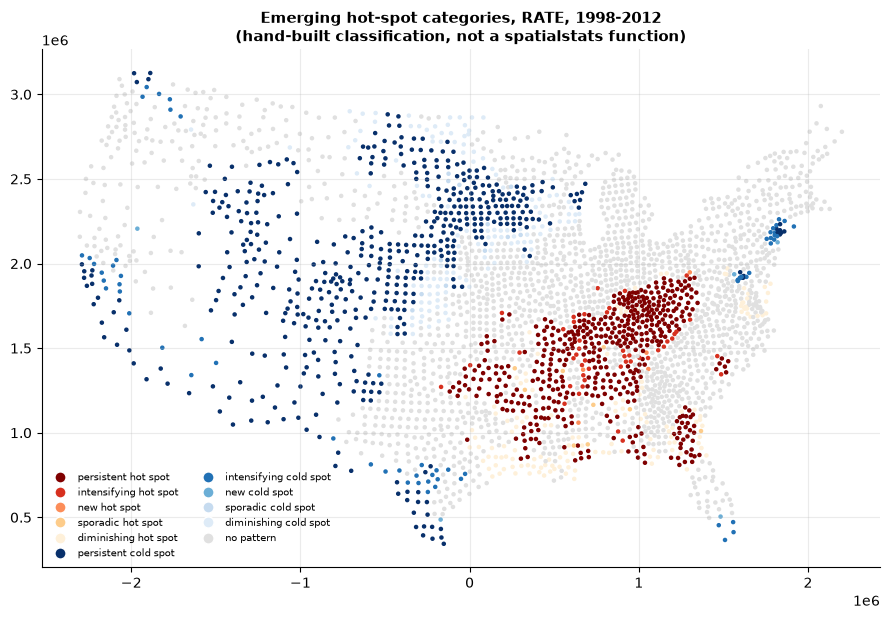

In [6]:
fig, ax = plt.subplots(figsize=(9, 8))
palette = {
    "persistent hot spot": "#7f0000", "intensifying hot spot": "#d7301f", "new hot spot": "#fc8d59",
    "sporadic hot spot": "#fdcc8a", "diminishing hot spot": "#fef0d9",
    "persistent cold spot": "#08306b", "intensifying cold spot": "#2171b5", "new cold spot": "#6baed6",
    "sporadic cold spot": "#c6dbef", "diminishing cold spot": "#deebf7",
    "oscillating": "#8c510a", "no pattern": "#e0e0e0",
}
colors = categories.map(palette).to_numpy()
ax.scatter(reference["X"], reference["Y"], c=colors, s=5)
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=lbl)
          for lbl, c in palette.items() if lbl in categories.unique()]
ax.legend(handles=handles, loc="lower left", fontsize=7, ncol=2)
ax.set_title("Emerging hot-spot categories, RATE, 1998-2012\n(hand-built classification, not a spatialstats function)")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("emerging_hotspots.png", dpi=100, bbox_inches="tight")
plt.show()

**Persistent hot and cold spots dominate** — the majority of counties with any significant pattern at all keep
it, essentially unchanged, across the full 15 years, consistent with Chapter 9.2's finding that clustering
weakens only gradually rather than reorganizing. The smaller **intensifying** and **diminishing** categories are
the genuinely informative ones for a policy audience: they flag *where* the geography of `RATE` is actually
shifting, not just confirming where it already was. **No county fell into the "oscillating" category** —
unsurprising, since flipping between a significant hot spot and a significant cold spot within 15 years would
require an extreme, fast reversal that a slowly-evolving health/socioeconomic measure like this one is unlikely
to show.

***
## 6. Multiple Testing Over Space x Time

Each of the 15 per-year `getis_ord_gi` calls already FDR-corrects across that year's 3,107 simultaneous county
tests (Chapter 4's practice, reused correctly here). But the *categorization* in Section 5 implicitly runs one
more test per county — the Mann-Kendall trend test — **without** any correction across the 3,107 counties being
tested simultaneously for a trend.

In [7]:
from spatialstats.esda import fdr_bh

raw_p = mk_df["p"].to_numpy()
reject_fdr, p_fdr = fdr_bh(raw_p, alpha=0.05)
print(f"Mann-Kendall trend significant at raw alpha=0.05:  {mk_df['significant'].sum()} of {n_counties} counties")
print(f"Mann-Kendall trend significant after FDR correction across counties: {reject_fdr.sum()} of {n_counties} counties")

Mann-Kendall trend significant at raw alpha=0.05:  2867 of 3107 counties
Mann-Kendall trend significant after FDR correction across counties: 2860 of 3107 counties


**Here, FDR correction barely moves the count at all** — 2,867 counties significant at raw $\alpha=0.05$ drops
to 2,860 after correcting across all 3,107 simultaneous tests, a difference of only 7 counties. That is itself a
real, informative finding, not a non-result: it means most of these 15-year trends have p-values far below
0.05 to begin with, so a handful of borderline counties are the only ones multiple-testing correction can
plausibly touch — the underlying trend signal (largely, a genuine nationwide decline in `RATE` over the period)
is strong and pervasive enough that correction is nearly a non-issue for this particular variable. That will not
be true in general: a noisier variable, a shorter time series, or a less pervasive trend would leave far more
counties' significance hinging on whether correction was applied. **The check is still worth running every
time** — this chapter only knows correction barely mattered *here* because it actually ran the comparison,
not because multiple-testing correction is somehow unnecessary for trend tests in general. A rigorous version of
this chapter's classification would still apply it, the same way Section 3 already corrects each year's spatial
step, precisely because the answer is not knowable in advance.

***
## 7. Summary and Conclusions

This chapter extended Chapter 9.2's global, year-by-year view down to the county level, and built — by hand,
transparently — the trend classification the outline calls for but the library does not implement.

### What we did

1. Ran `getis_ord_gi` independently for all 15 years, confirming the hot/cold footprint visibly shifts between
   1998 and 2012, not just its overall strength.
2. Ran a Mann-Kendall trend test on every county's 15-value z-score series using `pymannkendall`.
3. **Hand-assembled a 6-category emerging-hot-spot classification** (new, persistent, intensifying, diminishing,
   sporadic, oscillating) from the raw per-year results — a genuinely transparent, documented rule set, not a
   `spatialstats` function.
4. **Found persistent hot/cold spots dominate**, with intensifying/diminishing categories flagging the smaller
   set of counties where the geography is actually changing, and zero counties oscillating between hot and cold.
5. **Checked whether FDR-correcting the trend test across all 3,107 counties changes the picture, and found it
   barely does** (2,867 raw-significant counties drops to 2,860 after correction) — informative precisely because
   it shows this particular trend signal is pervasive enough that correction rarely matters here, not because
   the correction step itself is unnecessary in general.

### Practical takeaways

- A hand-built classification is only as trustworthy as its documented rules — Section 5's are given in full,
  specifically so they can be checked, adjusted, or replaced rather than trusted as a black box.
- Correcting each year's spatial test (Section 3) does not automatically correct the trend test run once per
  county (Section 4) — check both explicitly, as Section 6 did, rather than assuming the answer either way.
- A fading or strengthening local statistic is a genuinely different, complementary finding to a changing
  *global* one (Chapter 9.2) — both are worth checking, since neither implies the other.

### Next steps

**Chapter 9.4 (Space-Time Point Patterns and Density)** shifts from the county panel to the crime point data,
extending Part 1's kernel density estimation across a time-of-day dimension the same way this chapter extended
Gi* across years.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Gibbons, J. D. & Chakraborti, S. (2011). *Nonparametric Statistical Inference* (5th ed.). CRC Press. | The Mann-Kendall test's assumptions and small-sample behaviour, relevant to Section 4's 15-point series |

### Key papers

| Paper | Contribution |
|---|---|
| Mann, H. B. (1945). Nonparametric tests against trend. *Econometrica*, 13, 245–259. | The trend test used in Section 4 |
| Kendall, M. G. (1975). *Rank Correlation Methods* (4th ed.). Griffin. | The rank-correlation basis of the Mann-Kendall statistic |
| Getis, A. & Ord, J. K. (1992). *op. cit.* (Part 4) | The local Gi* statistic run independently per year in Section 3 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.cluster.getis_ord_gi` | Section 3 |
| `spatialstats.weights.KNN` | The fixed weights matrix reused across years |
| Chapter 9.2 | The global companion finding (declining Moran's I) this chapter's local view extends |